In [1]:
import sys, os
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sys.path.append(os.path.dirname(os.getcwd()))
from src.Predictor import Predictor
from src.PartialVAE import PartialVAE
from src.Flow import Flow
from train_utils import (
    set_seed,
    train_predictor,
    train_VAE,
    train_Flow,
    run_feature_acquisition,
    to_result_array
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Dataset

In [3]:
ROOT_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(ROOT_DIR, "data", "cube")

X_train = torch.load(f"{DATA_DIR}/X_train_cdf.pt").float()
y_train = torch.load(f"{DATA_DIR}/y_train.pt").long()

X_val   = torch.load(f"{DATA_DIR}/X_val_cdf.pt").float()
y_val   = torch.load(f"{DATA_DIR}/y_val.pt").long()

X_test = torch.load(f"{DATA_DIR}/X_test_cdf.pt").float()
y_test = torch.load(f"{DATA_DIR}/y_test.pt").long()

# Train Predictor

In [4]:
NUM_REPEATS = 5
batch_size = 128
epochs = 100
lr = 0.0003
weight_decay = 1e-4
D = 20  # feature 개수 고정

ckpt_dir = "/home/sulee/Gamma-CMI/checkpoints/cube/predictor"
os.makedirs(ckpt_dir, exist_ok=True)

for REPEAT in range(1, NUM_REPEATS+1):
    set_seed(REPEAT)
    predictor = Predictor(in_dim=20, hidden_dim=150, out_dim=8, num_hidden=2)
    optimizer = AdamW(predictor.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

    train_predictor(
        predictor=predictor,
        train_loader=train_loader,
        X_val=X_val,
        y_val=y_val,
        D=D,
        epochs=epochs,
        optimizer=optimizer,
        criterion=criterion,
        metric='accuracy'
    )

    ckpt_path = os.path.join(
        ckpt_dir,
        f"predictor_cube_repeat_{REPEAT}.pt"
    )
    torch.save(predictor.state_dict(), ckpt_path)

Epoch 1/1 | train_loss=1.1097 | val_loss=0.9104 | val_acc=0.6540 | lr=0.000300
Best validation accuracy = 0.6540
Epoch 1/1 | train_loss=1.1265 | val_loss=0.9279 | val_acc=0.6463 | lr=0.000300
Best validation accuracy = 0.6463
Epoch 1/1 | train_loss=1.1332 | val_loss=0.9451 | val_acc=0.6398 | lr=0.000300
Best validation accuracy = 0.6398
Epoch 1/1 | train_loss=1.1248 | val_loss=0.9435 | val_acc=0.6378 | lr=0.000300
Best validation accuracy = 0.6378
Epoch 1/1 | train_loss=1.1258 | val_loss=0.9223 | val_acc=0.6530 | lr=0.000300
Best validation accuracy = 0.6530


# Train Partial VAE

In [5]:
NUM_REPEATS = 5
batch_size = 256
epochs = 100
lr = 1e-3
weight_decay = 1e-4

ckpt_dir = "/home/sulee/Gamma-CMI/checkpoints/cube/generator"
os.makedirs(ckpt_dir, exist_ok=True)


for REPEAT in range(1, NUM_REPEATS+1):
    set_seed(REPEAT)
    pvae = PartialVAE(
        input_type="continuous",
        num_con_features=20,
        num_cat_features=0,
        hidden_dim_con=150,
        most_categories=max(1, 0),   # 내부 차원 계산을 위해 최소 1
        c_dim=6,
        hid_enc=100,
        hid_dec=100,
        latent_dim=30,
        num_hidden_emb=2,
        num_hidden_enc=2,
        num_hidden_dec=2
    )
    optimizer = AdamW(pvae.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_VAE(
        generator=pvae,
        train_loader=train_loader,
        X_val=X_val,
        D=D, # feature 개수
        epochs=epochs,
        optimizer=optimizer,
        obs_sigma=0.2,
        lr_factor=0.2,
        cooldown=0,
        min_lr=1e-7,
        scheduler_patience=5
    )

    ckpt_path = os.path.join(
        ckpt_dir,
        f"VAE_cube_repeat_{REPEAT}.pt"
    )
    torch.save(pvae.state_dict(), ckpt_path)

[PVAE ep 01] train_loss=13.2395  train_KL=1.8471  train_NLL_X=11.3924 | val_loss=11.8836  val_KL=1.2392  val_NLL_X=10.6443 | lr=0.001000
Best val_loss = 11.8836
[PVAE ep 01] train_loss=13.1979  train_KL=1.8179  train_NLL_X=11.3801 | val_loss=11.8348  val_KL=1.2845  val_NLL_X=10.5503 | lr=0.001000
Best val_loss = 11.8348
[PVAE ep 01] train_loss=13.1880  train_KL=1.9025  train_NLL_X=11.2854 | val_loss=11.9248  val_KL=1.2586  val_NLL_X=10.6662 | lr=0.001000
Best val_loss = 11.9248
[PVAE ep 01] train_loss=13.2338  train_KL=1.8174  train_NLL_X=11.4163 | val_loss=11.8269  val_KL=1.1921  val_NLL_X=10.6348 | lr=0.001000
Best val_loss = 11.8269
[PVAE ep 01] train_loss=13.2140  train_KL=1.9621  train_NLL_X=11.2519 | val_loss=11.9305  val_KL=1.2234  val_NLL_X=10.7071 | lr=0.001000
Best val_loss = 11.9305


# Train Flow

In [6]:
NUM_REPEATS = 5
batch_size = 256
epochs = 100
lr = 1e-3
weight_decay = 1e-4

ckpt_dir = "/home/sulee/Gamma-CMI/checkpoints/cube/generator"
os.makedirs(ckpt_dir, exist_ok=True)

for REPEAT in range(1, NUM_REPEATS+1):
    set_seed(REPEAT)
    flow = Flow(
        num_features=D,
        hidden_dim_flow=128,
        hidden_dim_prior=128,
        num_flow_layers=4,
        num_hidden=2,
    )

    train_Flow(
        generator=flow,
        train_loader=train_loader,
        X_val=X_val,
        D=D, # feature 개수
        epochs=epochs,
        optimizer=optimizer,
        lr_factor=0.2,
        cooldown=0,
        min_lr=1e-7,
        scheduler_patience=5
    )

    ckpt_path = os.path.join(
        ckpt_dir,
        f"Flow_cube_repeat_{REPEAT}.pt"
    )
    torch.save(flow.state_dict(), ckpt_path)

[Flow ep 00] train_loss=3.9886  train_NLL_xu=3.9886 | val_loss=4.0667  val_NLL_xu=4.0667 | lr=0.001000
Best val_loss = 4.0667
[Flow ep 00] train_loss=3.8050  train_NLL_xu=3.8050 | val_loss=3.9183  val_NLL_xu=3.9183 | lr=0.001000
Best val_loss = 3.9183
[Flow ep 00] train_loss=4.1313  train_NLL_xu=4.1313 | val_loss=4.5143  val_NLL_xu=4.5143 | lr=0.001000
Best val_loss = 4.5143
[Flow ep 00] train_loss=4.0974  train_NLL_xu=4.0974 | val_loss=4.2818  val_NLL_xu=4.2818 | lr=0.001000
Best val_loss = 4.2818
[Flow ep 00] train_loss=3.9630  train_NLL_xu=3.9630 | val_loss=4.0378  val_NLL_xu=4.0378 | lr=0.001000
Best val_loss = 4.0378


# Main Inference

In [4]:
result_vae = []
result_flow = []

NUM_REPEATS = 5

for REPEAT in range(1, NUM_REPEATS + 1):
    set_seed(REPEAT)
    predictor = Predictor(in_dim=20, hidden_dim=150, out_dim=8, num_hidden=2).to(device)

    pvae = PartialVAE(
        input_type="continuous",
        num_con_features=20,
        num_cat_features=0,
        hidden_dim_con=150,
        most_categories=max(1, 0),
        c_dim=6,
        hid_enc=100,
        hid_dec=100,
        latent_dim=30,
        num_hidden_emb=2,
        num_hidden_enc=2,
        num_hidden_dec=2
    ).to(device)

    flow = Flow(
        num_features=D,
        hidden_dim_flow=128,
        hidden_dim_prior=128,
        num_flow_layers=4,
        num_hidden=2,
    ).to(device)

    predictor.load_state_dict(torch.load(
        f"/home/sulee/Gamma-CMI/checkpoints/cube/predictor/predictor_cube_repeat_{REPEAT}.pt"
    ))
    pvae.load_state_dict(torch.load(
        f"/home/sulee/Gamma-CMI/checkpoints/cube/generator/VAE_cube_repeat_{REPEAT}.pt"
    ))
    flow.load_state_dict(torch.load(
        f"/home/sulee/Gamma-CMI/checkpoints/cube/generator/Flow_cube_repeat_{REPEAT}.pt"
    ))

    predictor.eval()
    pvae.eval()
    flow.eval()

    N = X_test.size(0)
    D = X_test.size(1)
    x_np = X_test.cpu().numpy()

    # VAE
    print(f'vae repeat {REPEAT}/{NUM_REPEATS}')
    m_np = np.zeros((N, D), dtype=np.float32)
    accs_vae = run_feature_acquisition(
        predictor=predictor,
        generator=pvae,
        X_test=X_test,
        y_test=y_test,
        x_np=x_np,
        m_np=m_np,
        D=D,
        num_samples=10,
        alpha=1,
        gamma=0.2,
        num_gamma_samples=5
    )
    result_vae.append(accs_vae)

    # Flow
    print(f'flow repeat {REPEAT}/{NUM_REPEATS}')
    m_np = np.zeros((N, D), dtype=np.float32)
    accs_flow = run_feature_acquisition(
        predictor=predictor,
        generator=flow,
        X_test=X_test,
        y_test=y_test,
        x_np=x_np,
        m_np=m_np,
        D=D,
        num_samples=10,
        alpha=1,
        gamma=0.2,
        num_gamma_samples=5
    )
    result_flow.append(accs_flow)

vae repeat 1/5
Step 1/20 | Acc: 0.2550
Step 2/20 | Acc: 0.4026
Step 3/20 | Acc: 0.5269
Step 4/20 | Acc: 0.6326
Step 5/20 | Acc: 0.7145
Step 6/20 | Acc: 0.7775
Step 7/20 | Acc: 0.8220
Step 8/20 | Acc: 0.8507
Step 9/20 | Acc: 0.8680
Step 10/20 | Acc: 0.8810
Step 11/20 | Acc: 0.8895
Step 12/20 | Acc: 0.8953
Step 13/20 | Acc: 0.8999
Step 14/20 | Acc: 0.9043
Step 15/20 | Acc: 0.9052
Step 16/20 | Acc: 0.9090
Step 17/20 | Acc: 0.9112
Step 18/20 | Acc: 0.9151
Step 19/20 | Acc: 0.9155
Step 20/20 | Acc: 0.9226
flow repeat 1/5
Step 1/20 | Acc: 0.2889
Step 2/20 | Acc: 0.4760
Step 3/20 | Acc: 0.6390
Step 4/20 | Acc: 0.7417
Step 5/20 | Acc: 0.8156
Step 6/20 | Acc: 0.8599
Step 7/20 | Acc: 0.8826
Step 8/20 | Acc: 0.8976
Step 9/20 | Acc: 0.9079
Step 10/20 | Acc: 0.9132
Step 11/20 | Acc: 0.9185
Step 12/20 | Acc: 0.9191
Step 13/20 | Acc: 0.9207
Step 14/20 | Acc: 0.9226
Step 15/20 | Acc: 0.9235
Step 16/20 | Acc: 0.9229
Step 17/20 | Acc: 0.9238
Step 18/20 | Acc: 0.9235
Step 19/20 | Acc: 0.9232
Step 20/20 |

# Result

In [7]:
def summarize_and_plot(result_list, title="Cube"):
    result = to_result_array(result_list)

    num_runs, D = result.shape
    row_means = result.mean(axis=1)
    overall_mean = row_means.mean()
    std = row_means.std()
    col_means = result.mean(axis=0)

    print("전체 평균:", overall_mean)
    print("표준편차:", std)
    # print("acquisition 별 평균):", col_means)

    # 시각화
    xs = np.arange(1, D + 1)

    plt.figure(figsize=(5, 4))
    plt.plot(xs, col_means, marker='o')
    plt.xlabel('Acquisition No.', fontsize=11)
    plt.ylabel('ACCURACY', fontsize=11)
    plt.title(title, fontsize=12)
    plt.xticks(np.arange(0, D+1, 2))
    plt.xlim(0, D + 1)
    plt.ylim(0.4, 1.0)
    plt.grid(True, alpha=0.3)

    # 확대 영역
    ax = plt.gca()
    axins = inset_axes(ax, width="50%", height="50%", loc='center right')

    axins.plot(xs, col_means, marker='o')
    axins.set_xlim(6, 8)
    axins.set_ylim(0.92, 0.98)
    axins.grid(True, alpha=0.3)
    axins.tick_params(labelsize=8)

    plt.show()

    return {
        "result": result,
        "means": row_means,
        "overall_mean": overall_mean,
        "std": std,
        "col_means": col_means,
    }


전체 평균: 0.796316
표준편차: 0.0070116036


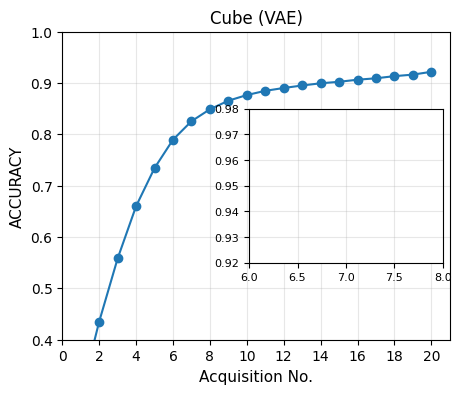

전체 평균: 0.82912904
표준편차: 0.00256013


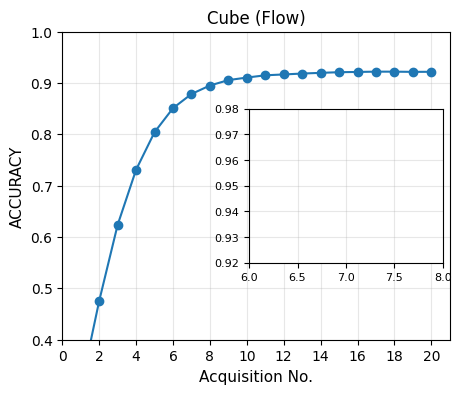

In [8]:
out_vae  = summarize_and_plot(result_vae,  title="Cube (VAE)")
out_flow = summarize_and_plot(result_flow, title="Cube (Flow)")